<a href="https://colab.research.google.com/github/markjschmidt/PET_List/blob/main/My_Claude_LOR_test_20260522.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Constants verified:
  1 TOF bin  = 2.9230 mm displacement from LOR midpoint
  CHWB=119 bins => max path = 695.7 mm = 2*R_FOV=700 mm  ✓
  676 mm chord (180° LOR) => tof_max_ring = 115.6 bins
  Speed of light check: C=0.299792 mm/ps  (= 0.299792, NOT 299.792 which is mm/ns)

  PET LOR Test Cases — 70 cm FOV Timing Check
  R_ring=338.0 mm   R_FOV=350.0 mm   C=0.299792 mm/ps   tof_scale=19.5 ps/bin   N=576
  1 TOF bin = 2.923 mm displacement of apparent annihilation from LOR midpoint
  dist_ctr_mm = sqrt(d_perp² + (|tof| × 2.923)²)  — must be ≤ 350.0 mm for 70 cm FOV


,Type,xa,xb,crystal_diff,chord_mm,tof (bins),tof_max_fov,dist_ctr_mm,within_FOV
#,,,,,,,,,
1,PROMPT,0,288,288,676.0,0,119.7,0.0,YES
2,PROMPT,0,288,288,676.0,58,119.7,169.5,YES
3,PROMPT,0,288,288,676.0,115,119.7,336.1,YES
4,PROMPT,0,288,288,676.0,118,119.7,344.9,YES
5,PROMPT,0,288,288,676.0,122,119.7,356.6,NO
6,PROMPT,0,288,288,676.0,130,119.7,380.0,NO
7,PROMPT,100,300,200,599.6,50,107.2,213.8,YES
8,PROMPT,100,300,200,599.6,108,107.2,352.2,NO
9,PROMPT,100,250,150,493.4,45,89.9,265.9,YES



Column guide:
  crystal_diff  = min(|xa-xb|, 576-|xa-xb|)   [ 288 = exactly opposite, short = small ]
  chord_mm      = 2 × R_ring × sin(crystal_diff × π / 576)
  tof_max_fov   = max |TOF| bins where annihilation is within the 70 cm FOV
  dist_ctr_mm   = distance of apparent annihilation from ring centre  (≤ 350 mm = inside)
  within_FOV    = YES if |tof| ≤ tof_max_fov



How to read the plot:
  Black curve  = tof_max_fov  (maximum |TOF| bins for the 70 cm FOV at each crystal_diff)
  Grey dotted  = tof_max_ring (maximum |TOF| for annihilation between the detector faces)
  Purple dash  = coincidence half-window  (±119 bins hardware limit)
  Red shading  = outside 70 cm FOV  (|TOF| > black curve)
  Orange zone  = inside FOV but beyond ring crystal face

  PROMPT events should cluster BELOW the black curve.
  DELAY (Random) events scatter uniformly up to ±119 bins regardless of LOR length.
  Short LORs (small crystal_diff) have a low black curve — Randoms stand out clearly there.


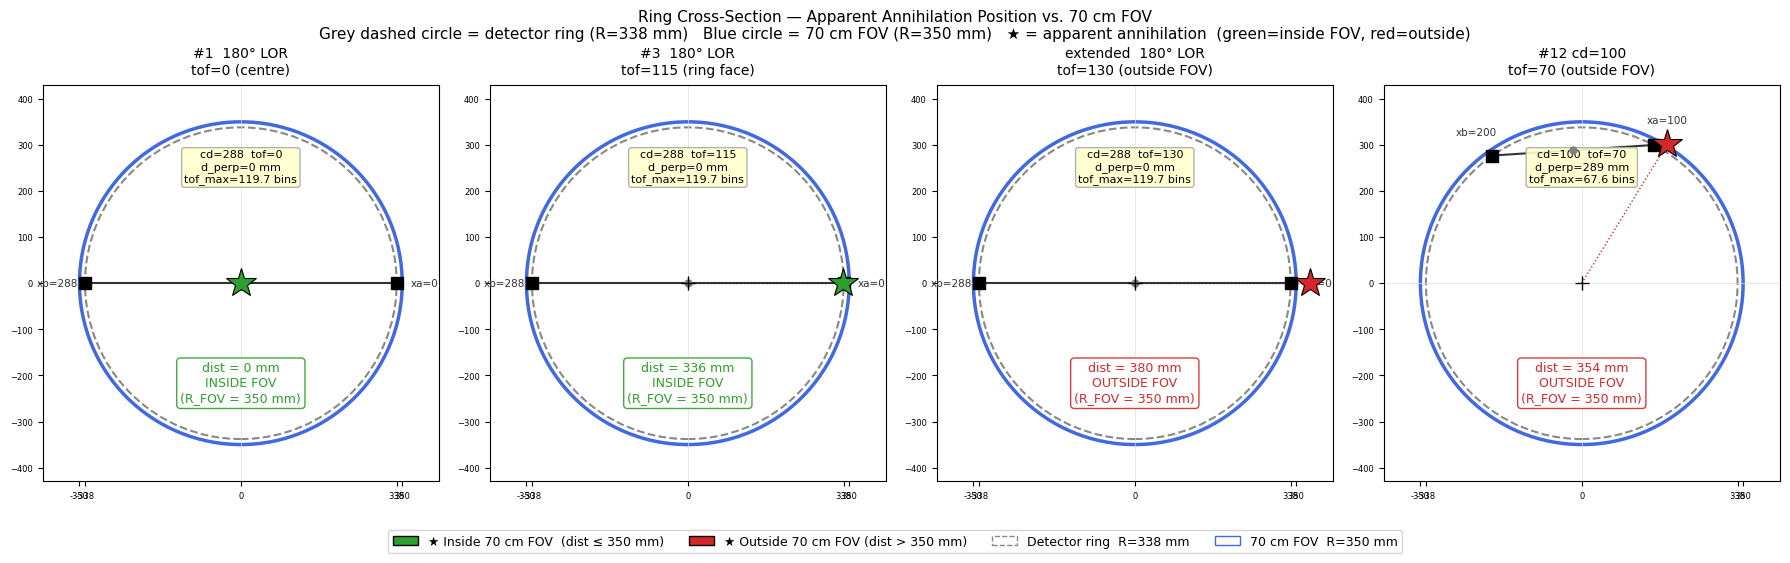


Note: R_ring=338 mm and R_FOV=350 mm are close together — both circles are visible
near the edge of each subplot.  The ★ star moves inward/outward as tof changes.
For the 180° LOR (panels 1–3), d_perp=0 so the midpoint is at the ring centre
and |dist| = |tof| × 2.923 mm directly.  For cd=100 (panel 4), the chord
midpoint is already 289 mm off-centre, so even moderate tof pushes past 350 mm.


In [ ]:
 # ============================================================
# PET LOR 70 cm FOV Timing Analysis — Self-Contained Demo
# Vereos Scanner: 576 crystals, 676 mm ring, 70 cm image FOV
#
# Paste each cell block into a separate Colab code cell,
# then run them top to bottom.
# ============================================================

# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — Constants, Helpers, Test Case Table           ║
# ╚══════════════════════════════════════════════════════════╝

import math
import numpy as np
import pandas as pd
from IPython.display import display

# ── Scanner constants ─────────────────────────────────────────────────────────
R_RING  = 338.0    # mm  — half the 676 mm face-to-face ring diameter
R_FOV   = 350.0    # mm  — 70 cm image FOV / 2  (= 700 mm / 2)
C       = 0.299792 # mm/ps  — speed of light  (NOT 299.792 — that is mm/ns!)
T_SCALE = 19.5     # ps/bin — tofTstampScale from scanner header
N       = 576      # crystals per ring
CHWB    = 119      # coincidence half-window bins

#  1 TOF bin => annihilation displaced C*T_SCALE/2 mm from LOR midpoint
BIN_TO_HALFMM = C * T_SCALE / 2.0   # 2.923 mm per bin

# ── Helper functions (scalar, work on single values or numpy arrays) ──────────
def get_crystal_diff(xa, xb):
    """Min crystal count between xa and xb (0–288)."""
    d = np.abs(np.asarray(xa, float) - np.asarray(xb, float))
    return np.minimum(d, N - d)

def get_chord_mm(xa, xb):
    """Chord length of the LOR in mm."""
    cd = get_crystal_diff(xa, xb)
    return 2.0 * R_RING * np.sin(cd * np.pi / N)

def get_d_perp(xa, xb):
    """Perpendicular distance from ring centre to LOR midpoint (mm)."""
    cd = get_crystal_diff(xa, xb)
    return R_RING * np.cos(cd * np.pi / N)

def get_tof_max_fov(xa, xb):
    """
    Maximum |TOF| in bins for a TRUE annihilation within the 70 cm FOV.
    Derived from:  tof_max = 2*sqrt(R_FOV^2 - d_perp^2) / (C * T_SCALE)
    At crystal_diff=288 (180° LOR):  tof_max = 2*350/5.846 = 119.7 ≈ CHWB ✓
    """
    d = get_d_perp(xa, xb)
    half_len = np.sqrt(np.maximum(R_FOV**2 - d**2, 0.0))
    return 2.0 * half_len / (C * T_SCALE)

def get_dist_from_center(xa, xb, tof):
    """
    Distance of apparent annihilation from ring centre (mm).
    = sqrt(d_perp^2 + (|tof| * BIN_TO_HALFMM)^2)
    For a TRUE event inside the 70 cm FOV this must be <= R_FOV.
    """
    d = get_d_perp(xa, xb)
    offset = np.abs(np.asarray(tof, float)) * BIN_TO_HALFMM
    return np.sqrt(d**2 + offset**2)

# ── Verification ──────────────────────────────────────────────────────────────
print("Constants verified:")
print(f"  1 TOF bin  = {BIN_TO_HALFMM:.4f} mm displacement from LOR midpoint")
print(f"  CHWB={CHWB} bins => max path = {CHWB*C*T_SCALE:.1f} mm = 2*R_FOV={2*R_FOV:.0f} mm  ✓")
print(f"  676 mm chord (180° LOR) => tof_max_ring = {676/(C*T_SCALE):.1f} bins")
print(f"  Speed of light check: C={C} mm/ps  (= 0.299792, NOT 299.792 which is mm/ns)\n")

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  TEST CASE TABLE                                                             ║
# ║  20 specific LORs spanning long/short, inside/outside, PROMPT/DELAY         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# Each row: (xa, xb, tof, is_delay, description)
#   crystal_diff = min(|xa-xb|, 576-|xa-xb|)   ranges 0 → 288
#   tof          = signed TOF bins from listPrint (or signed_tof_bin)
#   is_delay     = True for DELAY (Random) events, False for PROMPT
#
TEST_CASES = [
    # ── Full 180° LOR  (crystal_diff = 288, chord = 676 mm, d_perp = 0) ──────
    #    tof_max_fov = 119.7 bins   tof_max_ring = 115.6 bins
    (  0, 288,   0, False, "180° LOR  tof=0   — annihilation at centre (0 mm)"),
    (  0, 288,  58, False, "180° LOR  tof=58  — 169 mm from centre"),
    (  0, 288, 115, False, "180° LOR  tof=115 — 336 mm, at ring face (338 mm)"),
    (  0, 288, 118, False, "180° LOR  tof=118 — 344 mm, inside FOV, past ring face"),
    (  0, 288, 122, False, "180° LOR  tof=122 — 357 mm, OUTSIDE 70 cm FOV (>119.7)"),
    (  0, 288, 130, False, "180° LOR  tof=130 — 380 mm, clearly OUTSIDE FOV"),
    # ── Medium LOR  (crystal_diff = 200, chord = 600 mm, d_perp = 156 mm) ────
    #    tof_max_fov = 107.2 bins
    (100, 300,  50, False, "cd=200  tof=50  — 214 mm from centre, inside FOV"),
    (100, 300, 108, False, "cd=200  tof=108 — 352 mm, OUTSIDE FOV  (>107.2)"),
    # ── Shorter LOR  (crystal_diff = 150, chord = 493 mm, d_perp = 231 mm) ───
    #    tof_max_fov = 89.9 bins
    (100, 250,  45, False, "cd=150  tof=45  — 266 mm from centre, inside FOV"),
    (100, 250,  95, False, "cd=150  tof=95  — 361 mm, OUTSIDE FOV  (>89.9)"),
    # ── Short LOR  (crystal_diff = 100, chord = 351 mm, d_perp = 289 mm) ─────
    #    tof_max_fov = 67.6 bins   tof_max_ring = 60.0 bins
    (100, 200,  35, False, "cd=100  tof=35  — 307 mm from centre, inside FOV"),
    (100, 200,  70, False, "cd=100  tof=70  — 354 mm, OUTSIDE FOV  (>67.6)"),
    # ── Very short LOR  (crystal_diff = 50, chord = 182 mm, d_perp = 326 mm) ─
    #    tof_max_fov = 44.0 bins
    (100, 150,  20, False, "cd=50   tof=20  — 331 mm from centre, inside FOV"),
    (100, 150,  50, False, "cd=50   tof=50  — 357 mm, OUTSIDE FOV  (>44.0)"),
    # ── DELAY (Random coincidence) events ─────────────────────────────────────
    #    Random events have uncorrelated timing — any |tof| up to CHWB=119 bins
    (  0, 288, 100,  True, "DELAY 180°  tof=100 — random, within FOV timing"),
    (  0, 288, 119,  True, "DELAY 180°  tof=119 — random, at coincidence window edge"),
    (100, 300,  50,  True, "DELAY cd=200 tof=50  — random, within FOV timing"),
    (100, 300, 110,  True, "DELAY cd=200 tof=110 — random, OUTSIDE FOV (>107.2)"),
    (100, 200,  70,  True, "DELAY cd=100 tof=70  — random, OUTSIDE FOV (>67.6)"),
    (100, 150,  45,  True, "DELAY cd=50  tof=45  — random, OUTSIDE FOV (>44.0)"),
]

# Build the DataFrame
rows = []
for n, (xa, xb, tof, delay, desc) in enumerate(TEST_CASES, start=1):
    cd_val    = int(get_crystal_diff(xa, xb))
    chord_val = float(get_chord_mm(xa, xb))
    tmax_val  = float(get_tof_max_fov(xa, xb))
    dist_val  = float(get_dist_from_center(xa, xb, tof))
    inside    = abs(tof) <= tmax_val
    rows.append({
        '#':              n,
        'Type':           'DELAY' if delay else 'PROMPT',
        'xa':             xa,
        'xb':             xb,
        'crystal_diff':   cd_val,
        'chord_mm':       round(chord_val, 1),
        'tof (bins)':     tof,
        'tof_max_fov':    round(tmax_val, 1),
        'dist_ctr_mm':    round(dist_val, 1),
        'within_FOV':     'YES' if inside else 'NO',
        'Notes':          desc,
    })

df = pd.DataFrame(rows).set_index('#')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 60)

print("=" * 120)
print("  PET LOR Test Cases — 70 cm FOV Timing Check")
print(f"  R_ring={R_RING} mm   R_FOV={R_FOV} mm   C={C} mm/ps   tof_scale={T_SCALE} ps/bin   N={N}")
print(f"  1 TOF bin = {BIN_TO_HALFMM:.3f} mm displacement of apparent annihilation from LOR midpoint")
print(f"  dist_ctr_mm = sqrt(d_perp² + (|tof| × {BIN_TO_HALFMM:.3f})²)  — must be ≤ {R_FOV} mm for 70 cm FOV")
print("=" * 120)
display(df[['Type','xa','xb','crystal_diff','chord_mm','tof (bins)','tof_max_fov','dist_ctr_mm','within_FOV']])
print()
print("Column guide:")
print("  crystal_diff  = min(|xa-xb|, 576-|xa-xb|)   [ 288 = exactly opposite, short = small ]")
print("  chord_mm      = 2 × R_ring × sin(crystal_diff × π / 576)")
print("  tof_max_fov   = max |TOF| bins where annihilation is within the 70 cm FOV")
print("  dist_ctr_mm   = distance of apparent annihilation from ring centre  (≤ 350 mm = inside)")
print("  within_FOV    = YES if |tof| ≤ tof_max_fov")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Interactive Scatter: |TOF| vs crystal_diff  (Plotly)             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'colab'

df_plot = df.reset_index().copy()
df_plot['abs_tof'] = df_plot['tof (bins)'].abs()

# Classify into 4 groups for colour / symbol
def classify(row):
    inside = row['within_FOV'] == 'YES'
    prompt = row['Type'] == 'PROMPT'
    if prompt and inside:  return 'PROMPT — inside FOV'
    if prompt:             return 'PROMPT — outside FOV'
    if inside:             return 'DELAY  — inside FOV'
    return                        'DELAY  — outside FOV'

df_plot['group'] = df_plot.apply(classify, axis=1)

STYLE = {
    'PROMPT — inside FOV':  dict(color='#2ca02c', symbol='circle',  size=16),
    'PROMPT — outside FOV': dict(color='#d62728', symbol='circle',  size=16),
    'DELAY  — inside FOV':  dict(color='#1f77b4', symbol='diamond', size=16),
    'DELAY  — outside FOV': dict(color='#ff7f0e', symbol='diamond', size=16),
}

fig1 = go.Figure()

for grp, sty in STYLE.items():
    sub = df_plot[df_plot['group'] == grp]
    if len(sub) == 0:
        continue
    fig1.add_trace(go.Scatter(
        x=sub['crystal_diff'],
        y=sub['abs_tof'],
        mode='markers+text',
        marker=dict(
            size=sty['size'], color=sty['color'],
            symbol=sty['symbol'], opacity=0.9,
            line=dict(width=1.5, color='black')
        ),
        text=sub['#'].astype(str),
        textposition='top center',
        textfont=dict(size=9, color='black'),
        name=grp,
        customdata=sub[['xa','xb','tof (bins)','tof_max_fov',
                         'dist_ctr_mm','chord_mm','Notes']].values,
        hovertemplate=(
            '<b>Row #%{text}  —  ' + grp + '</b><br>'
            'xa=%{customdata[0]}  xb=%{customdata[1]}<br>'
            'crystal_diff=%{x}   |tof|=%{y} bins<br>'
            'tof_max_fov=%{customdata[3]} bins   '
            'dist_from_centre=%{customdata[4]} mm<br>'
            'chord=%{customdata[5]} mm<br>'
            '%{customdata[6]}<extra></extra>'
        ),
    ))

# ── Theoretical limit curves ──────────────────────────────────────────────────
cd_line = np.linspace(0, 288, 500)
d_line  = R_RING * np.cos(cd_line * np.pi / N)

# 70 cm FOV limit (black solid)
tmax_fov_line = 2.0 * np.sqrt(np.maximum(R_FOV**2 - d_line**2, 0.0)) / (C * T_SCALE)
fig1.add_trace(go.Scatter(
    x=cd_line, y=tmax_fov_line,
    mode='lines',
    line=dict(color='black', width=2.5),
    name='70 cm FOV limit  (tof_max_fov)',
    hovertemplate='crystal_diff=%{x:.0f}<br>tof_max_fov=%{y:.1f} bins<extra></extra>',
))

# Physical ring face limit (grey dotted)
chord_line     = 2.0 * R_RING * np.sin(cd_line * np.pi / N)
tmax_ring_line = chord_line / (C * T_SCALE)
fig1.add_trace(go.Scatter(
    x=cd_line, y=tmax_ring_line,
    mode='lines',
    line=dict(color='grey', width=1.5, dash='dot'),
    name='Ring face limit  (676 mm chord)',
    hovertemplate='crystal_diff=%{x:.0f}<br>tof_max_ring=%{y:.1f} bins<extra></extra>',
))

# Coincidence window
fig1.add_hline(
    y=CHWB, line_dash='dash', line_color='purple', line_width=1.5,
    annotation_text=f'Coincidence window  ±{CHWB} bins',
    annotation_position='top right',
)

# Shaded "outside FOV" region
fig1.add_trace(go.Scatter(
    x=np.concatenate([cd_line, cd_line[::-1]]),
    y=np.concatenate([tmax_fov_line, np.full(len(cd_line), CHWB + 3)[::-1]]),
    fill='toself',
    fillcolor='rgba(214,39,40,0.07)',
    line=dict(width=0),
    showlegend=True,
    name='Outside 70 cm FOV  (red shading)',
    hoverinfo='skip',
))

# Shaded "between ring face and FOV" region
fig1.add_trace(go.Scatter(
    x=np.concatenate([cd_line, cd_line[::-1]]),
    y=np.concatenate([tmax_ring_line, tmax_fov_line[::-1]]),
    fill='toself',
    fillcolor='rgba(255,127,14,0.10)',
    line=dict(width=0),
    showlegend=True,
    name='Between ring face & FOV edge  (orange shading)',
    hoverinfo='skip',
))

fig1.update_layout(
    title=dict(
        text=(
            '|TOF| vs Crystal Separation — 70 cm FOV Timing Check<br>'
            '<sup>Numbers = row # in table above  |  '
            'circles = PROMPT  |  diamonds = DELAY (Random)  |  '
            'green/blue = inside FOV  |  red/orange = outside FOV</sup>'
        ),
        font=dict(size=14),
    ),
    xaxis=dict(
        title='crystal_diff   (288 = exactly opposite / longest LOR,  0 = same side)',
        range=[-5, 298], gridcolor='#eeeeee',
    ),
    yaxis=dict(
        title='|TOF|  (bins)',
        range=[-3, 128], gridcolor='#eeeeee',
    ),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.85)',
                bordercolor='black', borderwidth=1),
    width=1000, height=650,
    plot_bgcolor='white', paper_bgcolor='white',
    hovermode='closest',
)

fig1.show()

print("\nHow to read the plot:")
print("  Black curve  = tof_max_fov  (maximum |TOF| bins for the 70 cm FOV at each crystal_diff)")
print("  Grey dotted  = tof_max_ring (maximum |TOF| for annihilation between the detector faces)")
print("  Purple dash  = coincidence half-window  (±119 bins hardware limit)")
print("  Red shading  = outside 70 cm FOV  (|TOF| > black curve)")
print("  Orange zone  = inside FOV but beyond ring crystal face")
print()
print("  PROMPT events should cluster BELOW the black curve.")
print("  DELAY (Random) events scatter uniformly up to ±119 bins regardless of LOR length.")
print("  Short LORs (small crystal_diff) have a low black curve — Randoms stand out clearly there.")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Ring Cross-Section Geometry  (Matplotlib)                        ║
# ║  Shows 4 cases: where the apparent annihilation lands in the scanner        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pick 4 instructive cases from the table
DIAGRAM_CASES = [
    (  0, 288,   0, False, "#1  180° LOR\ntof=0 (centre)"),
    (  0, 288, 115, False, "#3  180° LOR\ntof=115 (ring face)"),
    (  0, 288, 130, False, "extended  180° LOR\ntof=130 (outside FOV)"),
    (100, 200,  70, False, "#12 cd=100\ntof=70 (outside FOV)"),
]

fig2, axes = plt.subplots(1, 4, figsize=(18, 5.5))
fig2.suptitle(
    "Ring Cross-Section — Apparent Annihilation Position vs. 70 cm FOV\n"
    "Grey dashed circle = detector ring (R=338 mm)   "
    "Blue circle = 70 cm FOV (R=350 mm)   "
    "★ = apparent annihilation  (green=inside FOV, red=outside)",
    fontsize=11,
)

for ax, (xa, xb, tof, delay, title) in zip(axes, DIAGRAM_CASES):

    # ── Draw rings ──────────────────────────────────────────────────────────
    ring_circle = plt.Circle((0, 0), R_RING, fill=False,
                             color='#888888', linewidth=1.5, linestyle='--')
    fov_circle  = plt.Circle((0, 0), R_FOV,  fill=False,
                             color='royalblue', linewidth=2.5)
    ax.add_patch(ring_circle)
    ax.add_patch(fov_circle)

    # ── Crystal positions ────────────────────────────────────────────────────
    ang_a = xa / N * 2 * math.pi    # 0 rad = 3 o'clock (rightmost)
    ang_b = xb / N * 2 * math.pi
    Ax, Ay = R_RING * math.cos(ang_a), R_RING * math.sin(ang_a)
    Bx, By = R_RING * math.cos(ang_b), R_RING * math.sin(ang_b)

    # ── LOR chord ───────────────────────────────────────────────────────────
    ax.plot([Ax, Bx], [Ay, By], color='#333333', linewidth=1.5, zorder=3)
    ax.plot(Ax, Ay, 's', color='black', markersize=9, zorder=4)
    ax.plot(Bx, By, 's', color='black', markersize=9, zorder=4)
    ax.text(Ax * 1.18, Ay * 1.18, f'xa={xa}', fontsize=7.5,
            ha='center', va='center', color='#333333')
    ax.text(Bx * 1.18, By * 1.18, f'xb={xb}', fontsize=7.5,
            ha='center', va='center', color='#333333')

    # ── Midpoint M ──────────────────────────────────────────────────────────
    Mx, My = (Ax + Bx) / 2.0, (Ay + By) / 2.0
    ax.plot(Mx, My, 'o', color='grey', markersize=5, zorder=4)

    # ── Annihilation position ────────────────────────────────────────────────
    # tof_bins = -2*s/(C*T_SCALE)  =>  s = -tof * C * T_SCALE / 2
    #   s > 0  => displaced toward B along chord
    s = -float(tof) * C * T_SCALE / 2.0
    dlen = math.sqrt((Bx - Ax)**2 + (By - Ay)**2)
    ux, uy = (Bx - Ax) / dlen, (By - Ay) / dlen   # unit vector A→B
    Px, Py = Mx + s * ux, My + s * uy

    dist = math.sqrt(Px**2 + Py**2)
    inside = dist <= R_FOV
    star_color = '#2ca02c' if inside else '#d62728'

    ax.plot(Px, Py, '*', color=star_color, markersize=22, zorder=6,
            markeredgecolor='black', markeredgewidth=0.8)

    # ── Radial line centre → annihilation ────────────────────────────────────
    ax.plot([0, Px], [0, Py], color=star_color,
            linewidth=1.0, linestyle=':', zorder=2)
    ax.plot(0, 0, '+', color='black', markersize=10, zorder=5)

    # ── Distance annotation ───────────────────────────────────────────────────
    fov_str = "INSIDE FOV" if inside else "OUTSIDE FOV"
    ax.text(0, -R_FOV * 0.62,
            f'dist = {dist:.0f} mm\n{fov_str}\n(R_FOV = {R_FOV:.0f} mm)',
            ha='center', va='center', fontsize=9,
            color=star_color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=star_color, alpha=0.9))

    # ── d_perp annotation ────────────────────────────────────────────────────
    cd_val = int(get_crystal_diff(xa, xb))
    d_perp = float(get_d_perp(xa, xb))
    tmax_v = float(get_tof_max_fov(xa, xb))
    ax.text(0, R_FOV * 0.72,
            f'cd={cd_val}  tof={tof}\nd_perp={d_perp:.0f} mm\ntof_max={tmax_v:.1f} bins',
            ha='center', va='center', fontsize=8,
            color='black',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#ffffcc',
                      edgecolor='#aaaaaa', alpha=0.9))

    ax.set_xlim(-430, 430)
    ax.set_ylim(-430, 430)
    ax.set_aspect('equal')
    ax.axhline(0, color='#dddddd', linewidth=0.5, zorder=1)
    ax.axvline(0, color='#dddddd', linewidth=0.5, zorder=1)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xticks([-338, -350, 0, 350, 338])
    ax.set_xticklabels(['-338', '-350', '0', '350', '338'], fontsize=6)
    ax.tick_params(axis='y', labelsize=6)

# Legend patches
patches = [
    mpatches.Patch(facecolor='#2ca02c', edgecolor='black', label='★ Inside 70 cm FOV  (dist ≤ 350 mm)'),
    mpatches.Patch(facecolor='#d62728', edgecolor='black', label='★ Outside 70 cm FOV (dist > 350 mm)'),
    mpatches.Patch(facecolor='white',   edgecolor='#888888', linestyle='--', label='Detector ring  R=338 mm'),
    mpatches.Patch(facecolor='white',   edgecolor='royalblue', label='70 cm FOV  R=350 mm'),
]
fig2.legend(handles=patches, loc='lower center', ncol=4,
            fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print("\nNote: R_ring=338 mm and R_FOV=350 mm are close together — both circles are visible")
print("near the edge of each subplot.  The ★ star moves inward/outward as tof changes.")
print("For the 180° LOR (panels 1–3), d_perp=0 so the midpoint is at the ring centre")
print("and |dist| = |tof| × 2.923 mm directly.  For cd=100 (panel 4), the chord")
print("midpoint is already 289 mm off-centre, so even moderate tof pushes past 350 mm.")